## Data subset and baseline configuration.

In [6]:
!wget https://raw.githubusercontent.com/allenai/bi-att-flow/master/squad/evaluate-v1.1.py -O evaluate_v1.py
!pip install rank_bm25 -q


--2026-05-16 08:37:04--  https://raw.githubusercontent.com/allenai/bi-att-flow/master/squad/evaluate-v1.1.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3419 (3.3K) [text/plain]
Saving to: ‘evaluate_v1.py’

evaluate_v1.py      100%[===================>]   3.34K  --.-KB/s    in 0s      

2026-05-16 08:37:04 (46.5 MB/s) - ‘evaluate_v1.py’ saved [3419/3419]



In [7]:
import json
import urllib.request
import os
import re
from transformers import DistilBertTokenizerFast
from google.colab import userdata
from evaluate_v1 import normalize_answer, exact_match_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from rank_bm25 import BM25Okapi

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

# Global preprocessing storage
all_encodings = []
articles = []
train_articles = []
train_encoding_strided, train_input_ids, train_attention_masks, train_start_positions, train_end_positions = [], [], [], [], []
val_articles = []
val_encoding_strided, val_input_ids, val_attention_masks, val_start_positions, val_end_positions = [], [], [], [], []
test_articles = []
test_encoding_strided, test_input_ids, test_attention_masks, test_start_positions, test_end_positions = [], [], [], [], []

## Pre-processing Steps Include:
1.   Load SQuAD and inspect the JSON structure.
2.   Clean only lightly, not aggressively.
3.   Tokenize question and context together with special tokens.
4.   Use truncation and a stride/window approach.
5.   Compute answer start and end offsets.
6.   Create train/validation/test splits.

**Load SQuAD and inspect the JSON structure.**


*   Download Squad V2.0 both training and evaluation data.
*   List keys and investigate first 5 items.
*   Check that every ``answer_start`` offset in the dataset actually points to the correct position in the context string. (Sanity Check)




In [8]:
URLS = {
    "train_v1": "https://rajpurkar.github.io/SQuAD-explorer/dataset/train-v1.1.json"
}

for name, url in URLS.items():
    filename = url.split("/")[-1]
    if not os.path.exists(filename):
        print(f"Downloading {filename} ...")
        urllib.request.urlretrieve(url, filename)
    else:
        print(f"{filename} already exists, skipping download.")

with open("train-v1.1.json", "r", encoding="utf-8") as f:
    train_v1 = json.load(f)

print(f"SQuAD v1.1 - train articles: {len(train_v1['data'])}")

SQuAD v1.1 - train articles: 442


In [9]:
def print_keys(obj, indent=0):
    prefix = "  " * indent
    if isinstance(obj, dict):
        for key, value in obj.items():
            print(f"{prefix}- {key}")
            print_keys(value, indent + 1)
    elif isinstance(obj, list) and len(obj) > 0:
        print_keys(obj[0], indent + 1)

print("=== SQuAD v1.1 JSON Structure ===")
print_keys(train_v1)

=== SQuAD v1.1 JSON Structure ===
- data
    - title
    - paragraphs
        - context
        - qas
            - answers
                - answer_start
                - text
            - question
            - id
- version


In [10]:
count = 0
for article in train_v1["data"]:
    for para in article["paragraphs"]:
        for qa in para["qas"]:
            print(json.dumps({
                "title": article["title"],
                "context": para["context"][:150] + "...",
                "question": qa["question"],
                "answer_text": qa["answers"][0]["text"],
                "answer_start": qa["answers"][0]["answer_start"]
            }, indent=2))
            print("-" * 60)
            count += 1
            if count == 5:
                break
        if count == 5:
            break
    if count == 5:
        break

{
  "title": "University_of_Notre_Dame",
  "context": "Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front o...",
  "question": "To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?",
  "answer_text": "Saint Bernadette Soubirous",
  "answer_start": 515
}
------------------------------------------------------------
{
  "title": "University_of_Notre_Dame",
  "context": "Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front o...",
  "question": "What is in front of the Notre Dame Main Building?",
  "answer_text": "a copper statue of Christ",
  "answer_start": 188
}
------------------------------------------------------------
{
  "title": "University_of_Notre_Dame",
  "context": "Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden sta

In [11]:
total = 0
mismatches = []
for article in train_v1["data"]:
    for para in article["paragraphs"]:
        ctx = para["context"]
        for qa in para["qas"]:
            for ans in qa["answers"]:
                total += 1
                start = ans["answer_start"]
                end = start + len(ans["text"])
                extracted = ctx[start:end]
                if extracted != ans["text"]:
                    mismatches.append({
                        "id": qa["id"],
                        "expected": ans["text"],
                        "got": extracted
                    })

print(f"Checked  : {total} answer spans")
print(f"Mismatches: {len(mismatches)}")

if mismatches:
    print("\nFirst 3 mismatches:")
    for m in mismatches[:3]:
        print(f"  id={m['id']}  expected='{m['expected']}'  got='{m['got']}'")
else:
    print("All spans aligned correctly.")

Checked  : 87599 answer spans
Mismatches: 0
All spans aligned correctly.


**Clean only lightly, not aggressively.**


*    Collapse multiple spaces into one and strips leading/trailing whitespace.
*    Remove unanswerable questions, where ``is_impossible`` field distinguishes v2.0 from v1.1, it flags questions that have no answer in the context.

In [12]:
def clean_dataset(dataset):
    for article in train_v1["data"]:
      for para in article["paragraphs"]:
          para["context"] = re.sub(r" +", " ", para["context"]).strip()
          for qa in para["qas"]:
              qa["question"] = re.sub(r" +", " ", qa["question"]).strip()

    return dataset

In [13]:
train_v1 = clean_dataset(train_v1)

**Tokenize question and context together with special tokens.**
*   CPU time grows fast with sequence length, and a stride/window lets you keep contexts smaller while still preserving answers near boundaries.

In [14]:
def tokenize(sample_question, sample_context):
  document_stride = 128
  encoding_strided = tokenizer(
      sample_question,
      sample_context,
      truncation="only_second",
      max_length=512,
      stride=document_stride,
      return_overflowing_tokens=True,
      padding="max_length",
      return_offsets_mapping=True,
      return_tensors="pt"
  )
  return encoding_strided



In [15]:

sample_question = train_v1["data"][0]["paragraphs"][0]["qas"][0]["question"]
sample_context  = train_v1["data"][0]["paragraphs"][0]["context"]
encoding_strided = tokenize(sample_question, sample_context)

print(f"Number of chunks produced : {encoding_strided['input_ids'].shape[0]}")
print(f"Each chunk shape          : {encoding_strided['input_ids'].shape[1:]}")

for i in range(encoding_strided['input_ids'].shape[0]):
    tokens = encoding_strided['input_ids'][i].tolist()
    mask = encoding_strided['attention_mask'][i].tolist()
    real_tokens = mask.count(1)
    pad_tokens = mask.count(0)
    print(f"\nChunk {i+1}:")
    print(f"  Real tokens : {real_tokens}")
    print(f"  PAD tokens  : {pad_tokens}")
    print(f"  First 10 decoded: {tokenizer.convert_ids_to_tokens(tokens[:10])}")
    print(f"  Last  10 decoded: {tokenizer.convert_ids_to_tokens(tokens[-10:])}")

Number of chunks produced : 1
Each chunk shape          : torch.Size([512])

Chunk 1:
  Real tokens : 176
  PAD tokens  : 336
  First 10 decoded: ['[CLS]', 'to', 'whom', 'did', 'the', 'virgin', 'mary', 'allegedly', 'appear', 'in']
  Last  10 decoded: ['[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


**Compute answer start and end offsets**

In [16]:
def offset_mapping(answer, encoding_strided):
    ans_start = answer["answer_start"]
    ans_end   = ans_start + len(answer["text"])

    results = []

    for i in range(encoding_strided['input_ids'].shape[0]):
        offsets = encoding_strided['offset_mapping'][i].tolist()
        sequence_ids = encoding_strided.sequence_ids(i)  # tells us which tokens belong to the question (0) and which to the context (1)

        # Find where the context tokens start and end in this chunk
        ctx_start = next(j for j, s in enumerate(sequence_ids) if s == 1)
        ctx_end = len(sequence_ids) - 1 - next(j for j, s in enumerate(reversed(sequence_ids)) if s == 1)

        # Check if the answer is even inside this chunk
        if offsets[ctx_start][0] > ans_start or offsets[ctx_end][1] < ans_end:
            start_pos, end_pos = 0, 0
        else:
            # Walk tokens to find which one contains ans_start and ans_end
            start_pos = next((j for j in range(ctx_start, ctx_end+1) if offsets[j][0] <= ans_start < offsets[j][1]), ctx_start)
            end_pos = next((j for j in range(ctx_end, ctx_start-1, -1) if offsets[j][1] >= ans_end > offsets[j][0]), ctx_end)

        results.append((start_pos, end_pos))

    return results

In [17]:
sample_question = train_v1["data"][0]["paragraphs"][0]["qas"][0]["question"]
sample_context = train_v1["data"][0]["paragraphs"][0]["context"]
sample_answer = train_v1["data"][0]["paragraphs"][0]["qas"][0]["answers"][0]
encoding_strided = tokenize(sample_question, sample_context)
chunk_positions  = offset_mapping(sample_answer, encoding_strided)

print(f"Question : {sample_question}")
print(f"Answer   : {sample_answer}")
print(f"Context  : {sample_context[:150]}...")
print(f"Chunks   : {len(chunk_positions)}")

for i, (start_pos, end_pos) in enumerate(chunk_positions):
    print(f"\nChunk {i+1}: start_position={start_pos}, end_position={end_pos}")
    tokens = encoding_strided['input_ids'][i].tolist()
    if start_pos != 0 and end_pos != 0:
        predicted_answer = tokenizer.convert_tokens_to_string(
            tokenizer.convert_ids_to_tokens(tokens[start_pos:end_pos+1])
        )
        print(f"  Recovered answer: '{predicted_answer}'")
    else:
        print(f"  Answer not in this chunk")

Question : To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
Answer   : {'answer_start': 515, 'text': 'Saint Bernadette Soubirous'}
Context  : Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front o...
Chunks   : 1

Chunk 1: start_position=130, end_position=137
  Recovered answer: 'saint bernadette soubirous'


*Note: Runnig Time 4-5 minuites*

**Create train/validation/test splits**
*   Split train_v1 into 80/10/10 Splits.
*   Subset Filterin, slice train set down to 50k QA pairs.

In [18]:
import random

# Fix seed for reproducibility
random.seed(42)

# Get all articles and shuffle
articles = train_v1["data"].copy()
random.shuffle(articles)

# Split at article level 80/10/10
total = len(articles)
train_end = int(0.8 * total)
val_end = int(0.9 * total)

train_articles = articles[:train_end]
val_articles = articles[train_end:val_end]
test_articles = articles[val_end:]

print(f"Train articles      : {len(train_articles)}")
print(f"Validation articles : {len(val_articles)}")
print(f"Test articles       : {len(test_articles)}")

Train articles      : 353
Validation articles : 44
Test articles       : 45


In [19]:
subset_articles = []
qa_count = 0

for article in train_articles:
    article_qa = sum(len(para["qas"]) for para in article["paragraphs"])
    if qa_count <= 50000:
        subset_articles.append(article)
        qa_count += article_qa
    if qa_count >= 50000:
        break

train_articles = subset_articles
print(f"Subset articles : {len(train_articles)}")
print(f"Subset QA pairs : {qa_count}")

Subset articles : 245
Subset QA pairs : 50012


In [20]:
for article in train_articles:
    for para in article["paragraphs"]:
        for qa in para["qas"]:
            encoding_strided = tokenize(qa["question"], para["context"])
            answer = qa["answers"][0]
            chunk_positions = offset_mapping(answer, encoding_strided)

            for i, (start_pos, end_pos) in enumerate(chunk_positions):
                train_encoding_strided.append(encoding_strided)
                train_input_ids.append(encoding_strided['input_ids'][i].tolist())
                train_attention_masks.append(encoding_strided['attention_mask'][i].tolist())
                train_start_positions.append(start_pos)
                train_end_positions.append(end_pos)

In [21]:
for article in val_articles:
    for para in article["paragraphs"]:
        for qa in para["qas"]:
            encoding_strided = tokenize(qa["question"], para["context"])
            answer = qa["answers"][0]
            chunk_positions  = offset_mapping(answer, encoding_strided)

            for i, (start_pos, end_pos) in enumerate(chunk_positions):
                val_encoding_strided.append(encoding_strided)
                val_input_ids.append(encoding_strided['input_ids'][i].tolist())
                val_attention_masks.append(encoding_strided['attention_mask'][i].tolist())
                val_start_positions.append(start_pos)
                val_end_positions.append(end_pos)

In [22]:
for article in test_articles:
    for para in article["paragraphs"]:
        for qa in para["qas"]:
            encoding_strided = tokenize(qa["question"], para["context"])
            answer = qa["answers"][0]
            chunk_positions  = offset_mapping(answer, encoding_strided)

            for i, (start_pos, end_pos) in enumerate(chunk_positions):
                test_encoding_strided.append(encoding_strided)
                test_input_ids.append(encoding_strided['input_ids'][i].tolist())
                test_attention_masks.append(encoding_strided['attention_mask'][i].tolist())
                test_start_positions.append(start_pos)
                test_end_positions.append(end_pos)

In [23]:
print(f"Train chunks      : {len(train_input_ids)}")
print(f"Validation chunks : {len(val_input_ids)}")
print(f"Test chunks       : {len(test_input_ids)}")

Train chunks      : 50068
Validation chunks : 9308
Test chunks       : 8078


In [24]:
def count_qa(articles):
    return sum(
        len(para["qas"])
        for article in articles
        for para in article["paragraphs"]
    )

print(f"Train QA pairs      : {count_qa(train_articles)}")
print(f"Validation QA pairs : {count_qa(val_articles)}")
print(f"Test QA pairs       : {count_qa(test_articles)}")

Train QA pairs      : 50012
Validation QA pairs : 9303
Test QA pairs       : 8073


## Computing baseline EM and F1 scores using the official SQuAD evaluation script



In [25]:
baseline_predictions = {}
em_scores = []
f1_scores = []

for article in val_articles:
    for para in article["paragraphs"]:
        context  = para["context"]
        for qa in para["qas"]:
            question = qa["question"]
            gold_answers = [a["text"] for a in qa["answers"]]

            sentences = [s.strip() for s in re.split(r'(?<=[.!?])\s+', context) if s.strip()]
            if len(sentences) == 0:
                prediction = ""
            elif len(sentences) == 1:
                prediction = sentences[0]
            else:
                tokenized_sentences = [s.lower().split() for s in sentences]
                tokenized_question  = question.lower().split()
                bm25 = BM25Okapi(tokenized_sentences)
                scores = bm25.get_scores(tokenized_question)
                prediction = sentences[np.argmax(scores)]

            baseline_predictions[qa["id"]] = prediction
            em_scores.append(max(exact_match_score(a, prediction) for a in gold_answers))
            f1_scores.append(max(f1_score(a, prediction) for a in gold_answers))

avg_em = sum(em_scores) / len(em_scores) * 100
avg_f1 = sum(f1_scores) / len(f1_scores) * 100

print(f"BM25 Baseline Results on Validation Set")
print(f"Total examples : {len(em_scores)}")
print(f"Exact Match    : {avg_em:.2f}%")
print(f"F1 Score       : {avg_f1:.2f}%")

BM25 Baseline Results on Validation Set
Total examples : 9303
Exact Match    : 0.12%
F1 Score       : 14.19%


In [26]:
sample_para = val_articles[0]["paragraphs"][0]
sample_qa   = sample_para["qas"][0]
question    = sample_qa["question"]
context     = sample_para["context"]
gold        = [a["text"] for a in sample_qa["answers"]]

sentences = [s.strip() for s in re.split(r'(?<=[.!?])\s+', context) if s.strip()]
tokenized_sentences = [s.lower().split() for s in sentences]
tokenized_question  = question.lower().split()
bm25 = BM25Okapi(tokenized_sentences)
scores = bm25.get_scores(tokenized_question)
prediction = sentences[np.argmax(scores)]

print(f"Question    : {question}")
print(f"Gold answers: {gold}")
print(f"Prediction  : {prediction}")
print(f"EM          : {max(exact_match_score(a, prediction) for a in gold)}")
print(f"F1          : {max(f1_score(a, prediction) for a in gold):.4f}")

Question    : Who founded Philadelphia?
Gold answers: ['William Penn']
Prediction  : In 1682, William Penn founded the city to serve as capital of the Pennsylvania Colony.
EM          : False
F1          : 0.2667


In [27]:
with open("bm25_baseline_predictions.json", "w") as f:
    json.dump(baseline_predictions, f)

# Student B

## 🏗️ 4. Model Architecture — DistilBertForQuestionAnswering

In [28]:
import os, time, tracemalloc, random, warnings
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from datasets import load_dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForQuestionAnswering,
    TrainingArguments,
    Trainer,
    default_data_collator,
)

warnings.filterwarnings("ignore")

# ── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# ── Hardware ─────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda")
print(f"Using device: {DEVICE}")

# ── Hyperparameters ───────────────────────────────────────────────────────────
MODEL_CHECKPOINT  = "distilbert-base-uncased"
MAX_SEQ_LENGTH    = 384
STRIDE            = 128
BATCH_SIZE        = 16
GRAD_ACCUM_STEPS  = 2
NUM_EPOCHS        = 3
LEARNING_RATE     = 2e-5
WEIGHT_DECAY      = 0.01
OUTPUT_DIR        = "./distilbert-squad-output"

print("Configuration loaded ✅")

Using device: cuda
Configuration loaded ✅


# load data

In [29]:
# BUG FIX 1: build HuggingFace Datasets from the lists produced by Student A
#             (val_dataset was never defined; Student B referenced a non-existent variable)
# BUG FIX 2: train_input_ids is a plain list, not a Dataset — cannot call .set_format()
from datasets import Dataset

train_dataset = Dataset.from_dict({
    "input_ids":       train_input_ids,
    "attention_mask":  train_attention_masks,
    "start_positions": train_start_positions,
    "end_positions":   train_end_positions,
})

val_dataset = Dataset.from_dict({
    "input_ids":       val_input_ids,
    "attention_mask":  val_attention_masks,
    "start_positions": val_start_positions,
    "end_positions":   val_end_positions,
})

train_dataset.set_format("torch")
val_dataset.set_format("torch")

print(f"Train dataset : {len(train_dataset):,} chunks")
print(f"Val dataset   : {len(val_dataset):,} chunks")

Train dataset : 50,068 chunks
Val dataset   : 9,308 chunks


## 🏗️ 4. Model Architecture — DistilBertForQuestionAnswering

In [30]:
model = DistilBertForQuestionAnswering.from_pretrained(MODEL_CHECKPOINT).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model          : {MODEL_CHECKPOINT}")
print(f"Total params   : {total_params/1e6:.1f}M")
print(f"Trainable      : {trainable_params/1e6:.1f}M")
print(f"Layers         : 6 Transformer encoder layers")
print(f"Hidden size    : 768  |  Heads: 12  |  FFN: 3072")
print()
print(model)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForQuestionAnswering LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
qa_outputs.weight       | MISSING    | 
qa_outputs.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model          : distilbert-base-uncased
Total params   : 66.4M
Trainable      : 66.4M
Layers         : 6 Transformer encoder layers
Hidden size    : 768  |  Heads: 12  |  FFN: 3072

DistilBertForQuestionAnswering(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inpla

In [31]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [32]:
#train_dataset = train_dataset.select(range(10000))

## 🏋️ 5. Training + Loss Curves

Starting training...


Epoch,Training Loss,Validation Loss
1,1.450640,1.197852
2,1.153715,1.097957


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss
1,1.450640,1.197852
2,1.153715,1.097957
3,0.967704,1.091704


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


✅ Training complete — wall-clock time: 0.59 hours


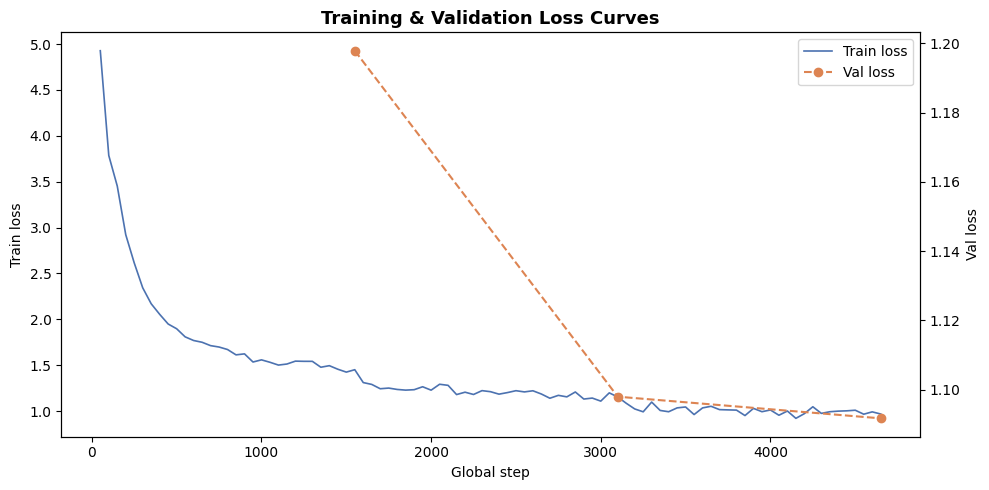

Loss curves saved → loss_curves.png


In [33]:


training_args = TrainingArguments(
    output_dir                  = OUTPUT_DIR,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    learning_rate               = LEARNING_RATE,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    gradient_accumulation_steps = GRAD_ACCUM_STEPS,
    num_train_epochs            = NUM_EPOCHS,
    weight_decay                = WEIGHT_DECAY,
    load_best_model_at_end      = True,
    metric_for_best_model       = "eval_loss",
    seed                        = SEED,
    logging_steps               = 50,
    report_to                   = "none",
    fp16=True
)

trainer = Trainer(
    model         = model,
    args          = training_args,
    train_dataset = train_dataset,
    eval_dataset  = val_dataset,
    data_collator = default_data_collator,
)

print("Starting training...")
train_start  = time.time()
train_output = trainer.train()
train_end    = time.time()
wall_clock_hrs = (train_end - train_start) / 3600
print(f"✅ Training complete — wall-clock time: {wall_clock_hrs:.2f} hours")

# ── Loss Curves ────────────────────────────────────────────────────────────────
log_history = trainer.state.log_history

train_steps  = [e["step"]      for e in log_history if "loss"      in e]
train_losses = [e["loss"]      for e in log_history if "loss"      in e]
eval_epochs  = [e["epoch"]     for e in log_history if "eval_loss" in e]
eval_losses  = [e["eval_loss"] for e in log_history if "eval_loss" in e]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_steps, train_losses, label="Train loss", color="#4C72B0", linewidth=1.2)
ax2 = ax.twinx()
total_train_steps  = train_steps[-1] if train_steps else 1
eval_steps_approx  = [int(e / NUM_EPOCHS * total_train_steps) for e in eval_epochs]
ax2.plot(eval_steps_approx, eval_losses, "o--", label="Val loss", color="#DD8452", linewidth=1.5)

ax.set_xlabel("Global step")
ax.set_ylabel("Train loss")
ax2.set_ylabel("Val loss")
ax.set_title("Training & Validation Loss Curves", fontsize=13, fontweight="bold")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.tight_layout()
plt.savefig("loss_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("Loss curves saved → loss_curves.png")

In [34]:
SAVE_PATH = "./distilbert-squad-final"
model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print(f"Model and tokenizer saved → {SAVE_PATH}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved → ./distilbert-squad-final


In [ ]:
from transformers import pipeline

qa_pipeline = pipeline("question-answering", model=SAVE_PATH, tokenizer=SAVE_PATH, device=-1)

demos = [
    {"question": "Who introduced BERT?",
     "context": "BERT was introduced by Devlin et al. from Google AI Language in 2019. "
                "It achieved state-of-the-art results on eleven NLP tasks."},
    {"question": "How many parameters does DistilBERT have?",
     "context": "DistilBERT, proposed by Sanh et al., reduces BERT's parameter count "
                "by 40%, resulting in approximately 66 million parameters while retaining "
                "97% of BERT's language understanding capability."},
    {"question": "What dataset was used for evaluation?",
     "context": "The model was evaluated on SQuAD v1.1, which contains over 107,000 "
                "question-answer pairs from 536 Wikipedia articles."},
]

print("── Inference Demo ──────────────────────────────────────")
for d in demos:
    ans = qa_pipeline(question=d["question"], context=d["context"])
    print(f"Q: {d['question']}")
    print(f"A: {ans['answer']}  (score: {ans['score']:.4f})")
    print()


In [36]:
import time
import torch

# 1. تحديد الجهاز كـ CPU
device_cpu = torch.device("cpu")

# نقل الموديل للـ CPU
model.to(device_cpu)
model.eval()

# 2. تجهيز سؤال ونص تجريبي

sample_para = val_articles[0]["paragraphs"][0]
sample_qa   = sample_para["qas"][0]
question    = sample_qa["question"]
context     = sample_para["context"]

# 3. Tokenization
inputs = tokenizer(
    question,
    context,
    max_length=384,
    truncation="only_second",
    return_tensors="pt"
)

# نقل الـ tensors للـ CPU
inputs = {k: v.to(device_cpu) for k, v in inputs.items()}

# 4. قياس زمن الـ inference
start_time = time.time()

with torch.no_grad():
    outputs = model(**inputs)

end_time = time.time()

cpu_latency = (end_time - start_time) * 1000

print(f"✅ Question: {question}")
print(f"🚀 Inference time on CPU: {cpu_latency:.2f} ms")

# لو هتكمل تدريب/تجارب على GPU
# model.to("cuda")

✅ Question: Who founded Philadelphia?
🚀 Inference time on CPU: 140.13 ms


# Student C for the evaluation and error analysis

This section is my part of the project. I evaluate the baseline and the fine-tuned DistilBERT model using the official SQuAD-style metrics, then I compare the results and inspect some wrong predictions. The goal is not only to report numbers, but also to understand what kinds of mistakes the model still makes.


## Evaluation Setup

For evaluation, I use Exact Match and F1 score. Exact Match checks if the predicted answer is exactly the same as a correct answer after normalization. F1 is more flexible because it gives partial credit when the predicted answer shares words with the correct answer.

I use the same scoring function for both the BM25 baseline and DistilBERT so the comparison is fair.


In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import torch
from transformers import pipeline

# I use a smaller number first so evaluation does not take too long.
EVAL_LIMIT = 500


def get_validation_examples(articles, limit=None):
    examples = []

    for article in articles:
        title = article.get("title", "")

        for para in article["paragraphs"]:
            context = para["context"]

            for qa in para["qas"]:
                # Some datasets may contain unanswerable questions, so I skip them here.
                if len(qa["answers"]) == 0:
                    continue

                examples.append({
                    "id": qa["id"],
                    "title": title,
                    "question": qa["question"],
                    "context": context,
                    "gold_answers": [a["text"] for a in qa["answers"]]
                })

                if limit is not None and len(examples) >= limit:
                    return examples

    return examples


def score_prediction(gold_answers, prediction):
    # SQuAD gives the prediction the best score over all available gold answers.
    em = max(compute_exact(gold, prediction) for gold in gold_answers)
    f1 = max(compute_f1(gold, prediction) for gold in gold_answers)
    return em, f1


val_examples = get_validation_examples(val_articles, limit=EVAL_LIMIT)

print(f"Validation examples used: {len(val_examples)}")


Validation examples used: 500


## Baseline Evaluation

First, I evaluate the BM25 baseline. This baseline chooses a sentence from the context based on word overlap with the question. It is much simpler than DistilBERT, but it gives us a useful starting point for comparison.


In [98]:
baseline_rows = []

for ex in val_examples:
    prediction = baseline_predictions.get(ex["id"], "")
    em, f1 = score_prediction(ex["gold_answers"], prediction)

    baseline_rows.append({
        "id": ex["id"],
        "title": ex["title"],
        "question": ex["question"],
        "gold_answers": " | ".join(ex["gold_answers"]),
        "prediction": prediction,
        "em": em,
        "f1": f1
    })

baseline_df = pd.DataFrame(baseline_rows)

baseline_em = baseline_df["em"].mean() * 100
baseline_f1 = baseline_df["f1"].mean() * 100

print("BM25 Baseline Results")
print(f"Exact Match: {baseline_em:.2f}%")
print(f"F1 Score   : {baseline_f1:.2f}%")

baseline_df.to_csv("baseline_results.csv", index=False)
baseline_df.head()


BM25 Baseline Results
Exact Match: 0.00%
F1 Score   : 12.75%


,id,title,question,gold_answers,prediction,em,f1
0,572a8d2834ae481900deab79,Philadelphia,Who founded Philadelphia?,William Penn,"In 1682, William Penn founded the city to serv...",0,0.266667
1,572a8d2834ae481900deab7a,Philadelphia,What role did Philadelphia play in the America...,a meeting place for the Founding Fathers,Philadelphia played an instrumental role in th...,0,0.312500
2,572a8d2834ae481900deab7b,Philadelphia,What purpose did Philadelphia serve while D.C....,temporary U.S. capital,"capital while Washington, D.C., was under cons...",0,0.200000
3,572a8d2834ae481900deab7c,Philadelphia,When did it reach 2 million occupants>,1950,It became a prime destination for African-Amer...,0,0.117647
4,572a8e0834ae481900deab81,Philadelphia,What was the historical economic base of Phila...,manufacturing,The economic impact of these changes would red...,0,0.000000


## DistilBERT Evaluation

Next, I evaluate the fine-tuned DistilBERT model. For each validation example, the model receives the question and context, then returns the answer span it thinks is most likely. I save the prediction, confidence score, Exact Match, and F1 score so these results can be used later in the report.


In [99]:
device = 0 if torch.cuda.is_available() else -1

qa_pipeline = pipeline(
    "question-answering",
    model=SAVE_PATH,
    tokenizer=SAVE_PATH,
    device=device
)

model_rows = []
start_time = time.time()

for i, ex in enumerate(val_examples):
    output = qa_pipeline(
        question=ex["question"],
        context=ex["context"],
        max_answer_len=40
    )

    prediction = output["answer"]
    em, f1 = score_prediction(ex["gold_answers"], prediction)

    model_rows.append({
        "id": ex["id"],
        "title": ex["title"],
        "question": ex["question"],
        "gold_answers": " | ".join(ex["gold_answers"]),
        "prediction": prediction,
        "confidence": output["score"],
        "em": em,
        "f1": f1
    })

    # This progress message helps while the cell is running.
    if (i + 1) % 50 == 0:
        print(f"Evaluated {i + 1}/{len(val_examples)} examples")

total_time = time.time() - start_time

model_df = pd.DataFrame(model_rows)

model_em = model_df["em"].mean() * 100
model_f1 = model_df["f1"].mean() * 100
avg_latency = total_time / len(val_examples)

print("DistilBERT Results")
print(f"Exact Match       : {model_em:.2f}%")
print(f"F1 Score          : {model_f1:.2f}%")
print(f"Average latency   : {avg_latency:.4f} seconds/example")

model_df.to_csv("distilbert_results.csv", index=False)
model_df.head()


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Evaluated 50/500 examples
Evaluated 100/500 examples
Evaluated 150/500 examples
Evaluated 200/500 examples
Evaluated 250/500 examples
Evaluated 300/500 examples
Evaluated 350/500 examples
Evaluated 400/500 examples
Evaluated 450/500 examples
Evaluated 500/500 examples
DistilBERT Results
Exact Match       : 67.40%
F1 Score          : 78.42%
Average latency   : 0.0084 seconds/example


,id,title,question,gold_answers,prediction,confidence,em,f1
0,572a8d2834ae481900deab79,Philadelphia,Who founded Philadelphia?,William Penn,William Penn,0.991079,1,1.0
1,572a8d2834ae481900deab7a,Philadelphia,What role did Philadelphia play in the America...,a meeting place for the Founding Fathers,instrumental,0.117428,0,0.0
2,572a8d2834ae481900deab7b,Philadelphia,What purpose did Philadelphia serve while D.C....,temporary U.S. capital,temporary U.S. capital,0.778402,1,1.0
3,572a8d2834ae481900deab7c,Philadelphia,When did it reach 2 million occupants>,1950,1950,0.943892,1,1.0
4,572a8e0834ae481900deab81,Philadelphia,What was the historical economic base of Phila...,manufacturing,manufacturing,0.980238,1,1.0


## Comparison Between Baseline and DistilBERT

After evaluating both methods, I compare their Exact Match and F1 scores. This shows whether the fine-tuned transformer model improves over the simple BM25 baseline.


In [100]:
comparison_df = pd.DataFrame({
    "Model": ["BM25 Baseline", "DistilBERT"],
    "Exact Match": [baseline_em, model_em],
    "F1 Score": [baseline_f1, model_f1]
})

comparison_df.to_csv("comparison_table.csv", index=False)
comparison_df


,Model,Exact Match,F1 Score
0,BM25 Baseline,0.0,12.747165
1,DistilBERT,67.4,78.422384


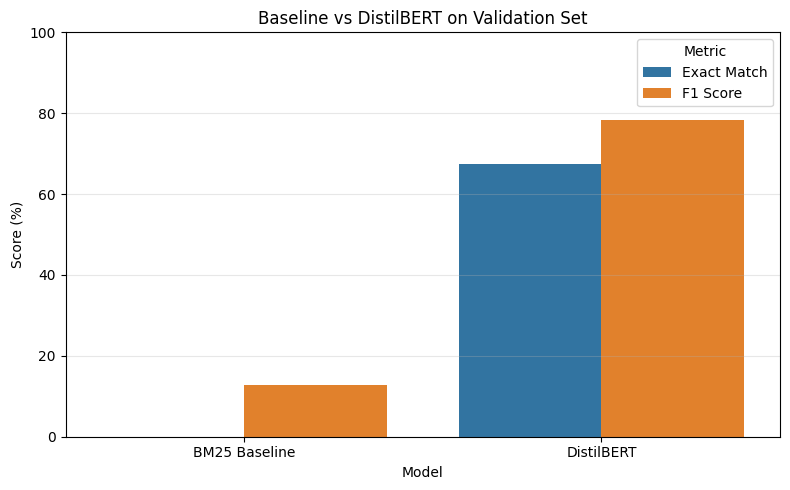

In [101]:
plot_df = comparison_df.melt(
    id_vars="Model",
    value_vars=["Exact Match", "F1 Score"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(8, 5))
sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric")

plt.title("Baseline vs DistilBERT on Validation Set")
plt.ylabel("Score (%)")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig("em_f1_comparison.png", dpi=150)
plt.show()


## Error Analysis

The scores give a general view of performance, but they do not show why the model fails. For this reason, I inspect a small set of wrong predictions. I start with examples where Exact Match is zero, then look at whether the answer is partially correct, too long, related but incorrect, or completely wrong.


In [102]:
wrong_examples = model_df[model_df["em"] == 0].copy()

# Sorting by F1 puts the weakest predictions first.
wrong_examples = wrong_examples.sort_values("f1").head(15)

wrong_examples[[
    "question",
    "gold_answers",
    "prediction",
    "em",
    "f1"
]].to_csv("wrong_examples.csv", index=False)

wrong_examples[[
    "question",
    "gold_answers",
    "prediction",
    "em",
    "f1"
]]


,question,gold_answers,prediction,em,f1
1,What role did Philadelphia play in the America...,a meeting place for the Founding Fathers,instrumental,0,0.0
9,Where does it rank in comparison to other US c...,fourth,ninth,0,0.0
16,Where did the Lenape go after being pushed out...,upper Ohio River basin,expanding European colonies,0,0.0
36,Which were the two biggest immigrant groups in...,Irish and German,textiles,0,0.0
48,What is the main driver of the economy now?,service businesses,the restructuring of industry,0,0.0
49,How much of the population left after 1950?,one-quarter,more than two million,0,0.0
50,What is another large industry?,a tourist destination,middle-class union jobs,0,0.0
64,What is the tallest building?,Comcast Center,The 548 ft (167 m) City Hall,0,0.0
83,How much is the population predicted to grow b...,"100,000","1,630,000",0,0.0
84,What is the percent of blacks?,43.4%,41.0%,0,0.0


## Suggested Error Categories

The next cell gives simple suggested categories for the wrong examples. These labels are not meant to be perfect. I use them as a first pass, then manually inspect the examples and adjust the final explanation in the report if needed.


In [103]:
def categorize_error(row):
    gold = row["gold_answers"].lower()
    pred = row["prediction"].lower()

    if pred.strip() == "":
        return "empty prediction"

    if row["f1"] > 0.6:
        return "partially correct span"

    if len(pred.split()) > 15:
        return "answer too long"

    if any(token in pred for token in gold.split()):
        return "related but wrong span"

    return "wrong answer"


wrong_examples["suggested_error_type"] = wrong_examples.apply(categorize_error, axis=1)

# These are rule-based suggestions only.
# I will inspect the examples manually when writing the report.
error_summary = wrong_examples["suggested_error_type"].value_counts().reset_index()
error_summary.columns = ["Suggested Error Type", "Count"]

wrong_examples.to_csv("wrong_examples_with_categories.csv", index=False)
error_summary.to_csv("error_summary.csv", index=False)

error_summary

,Suggested Error Type,Count
0,wrong answer,13
1,related but wrong span,2


In [104]:
wrong_examples[[
    "question",
    "gold_answers",
    "prediction",
    "f1",
    "suggested_error_type"
]]

,question,gold_answers,prediction,f1,suggested_error_type
1,What role did Philadelphia play in the America...,a meeting place for the Founding Fathers,instrumental,0.0,related but wrong span
9,Where does it rank in comparison to other US c...,fourth,ninth,0.0,wrong answer
16,Where did the Lenape go after being pushed out...,upper Ohio River basin,expanding European colonies,0.0,wrong answer
36,Which were the two biggest immigrant groups in...,Irish and German,textiles,0.0,wrong answer
48,What is the main driver of the economy now?,service businesses,the restructuring of industry,0.0,wrong answer
49,How much of the population left after 1950?,one-quarter,more than two million,0.0,wrong answer
50,What is another large industry?,a tourist destination,middle-class union jobs,0.0,related but wrong span
64,What is the tallest building?,Comcast Center,The 548 ft (167 m) City Hall,0.0,wrong answer
83,How much is the population predicted to grow b...,"100,000","1,630,000",0.0,wrong answer
84,What is the percent of blacks?,43.4%,41.0%,0.0,wrong answer


## Small Robustness Check With Reworded Questions

The project also asks about robustness. As a small first check, I test the model on a few reworded questions. The context and correct answer stay the same, but the question wording changes. If the score drops after rewording, this suggests the model is sensitive to question phrasing.



In [105]:
robustness_examples = []

manual_paraphrases = [
    "Which person founded Philadelphia?",
    "How was Philadelphia important during the American Revolution?",
    "What function did Philadelphia have before Washington, D.C. was completed?",
    "In what year did the population reach 2 million?",
    "What was Philadelphia's economy mainly based on historically?",
    "When did the city come close to bankruptcy?",
    "Where did rich residents move?",
    "Who took the place of the wealthy residents?",
    "What is the city's GDP?",
    "How does it rank compared with other cities in the United States?"
]

for ex, paraphrased_q in zip(val_examples[:10], manual_paraphrases):
    robustness_examples.append({
        **ex,
        "original_question": ex["question"],
        "paraphrased_question": paraphrased_q
    })

robustness_df = pd.DataFrame(robustness_examples)
robustness_df[["original_question", "paraphrased_question", "gold_answers"]]

,original_question,paraphrased_question,gold_answers
0,Who founded Philadelphia?,Which person founded Philadelphia?,[William Penn]
1,What role did Philadelphia play in the America...,How was Philadelphia important during the Amer...,[a meeting place for the Founding Fathers]
2,What purpose did Philadelphia serve while D.C....,What function did Philadelphia have before Was...,[temporary U.S. capital]
3,When did it reach 2 million occupants>,In what year did the population reach 2 million?,[1950]
4,What was the historical economic base of Phila...,What was Philadelphia's economy mainly based o...,[manufacturing]
5,When did the city near bankruptcy?,When did the city come close to bankruptcy?,[late 1980s]
6,Where did wealthy residents move?,Where did rich residents move?,[suburbs]
7,Who replaced the wealthy?,Who took the place of the wealthy residents?,[immigrants]
8,What is the GDP of the city?,What is the city's GDP?,[$388 billion]
9,Where does it rank in comparison to other US c...,How does it rank compared with other cities in...,[fourth]


In [106]:
robustness_rows = []

for ex in robustness_examples:
    original_output = qa_pipeline(
        question=ex["original_question"],
        context=ex["context"],
        max_answer_len=40
    )
    para_output = qa_pipeline(
        question=ex["paraphrased_question"],
        context=ex["context"],
        max_answer_len=40
    )

    original_em, original_f1 = score_prediction(ex["gold_answers"], original_output["answer"])
    para_em, para_f1 = score_prediction(ex["gold_answers"], para_output["answer"])

    robustness_rows.append({
        "id": ex["id"],
        "original_question": ex["original_question"],
        "paraphrased_question": ex["paraphrased_question"],
        "gold_answers": " | ".join(ex["gold_answers"]),
        "original_prediction": original_output["answer"],
        "paraphrased_prediction": para_output["answer"],
        "original_em": original_em,
        "paraphrased_em": para_em,
        "original_f1": original_f1,
        "paraphrased_f1": para_f1
    })

robustness_results_df = pd.DataFrame(robustness_rows)
robustness_results_df.to_csv("robustness_results.csv", index=False)

print("Original questions")
print(f"Exact Match: {robustness_results_df['original_em'].mean() * 100:.2f}%")
print(f"F1 Score   : {robustness_results_df['original_f1'].mean() * 100:.2f}%")

print("Paraphrased questions")
print(f"Exact Match: {robustness_results_df['paraphrased_em'].mean() * 100:.2f}%")
print(f"F1 Score   : {robustness_results_df['paraphrased_f1'].mean() * 100:.2f}%")

robustness_results_df


Original questions
Exact Match: 70.00%
F1 Score   : 72.00%
Paraphrased questions
Exact Match: 70.00%
F1 Score   : 75.71%


,id,original_question,paraphrased_question,gold_answers,original_prediction,paraphrased_prediction,original_em,paraphrased_em,original_f1,paraphrased_f1
0,572a8d2834ae481900deab79,Who founded Philadelphia?,Which person founded Philadelphia?,William Penn,William Penn,William Penn,1,1,1.0,1.000000
1,572a8d2834ae481900deab7a,What role did Philadelphia play in the America...,How was Philadelphia important during the Amer...,a meeting place for the Founding Fathers,instrumental,a meeting place,0,0,0.0,0.571429
2,572a8d2834ae481900deab7b,What purpose did Philadelphia serve while D.C....,What function did Philadelphia have before Was...,temporary U.S. capital,temporary U.S. capital,temporary U.S. capital,1,1,1.0,1.000000
3,572a8d2834ae481900deab7c,When did it reach 2 million occupants>,In what year did the population reach 2 million?,1950,1950,1950,1,1,1.0,1.000000
4,572a8e0834ae481900deab81,What was the historical economic base of Phila...,What was Philadelphia's economy mainly based o...,manufacturing,manufacturing,manufacturing,1,1,1.0,1.000000
5,572a8e0834ae481900deab82,When did the city near bankruptcy?,When did the city come close to bankruptcy?,late 1980s,late 1980s,late 1980s,1,1,1.0,1.000000
6,572a8e0834ae481900deab83,Where did wealthy residents move?,Where did rich residents move?,suburbs,suburbs,suburbs,1,1,1.0,1.000000
7,572a8e0834ae481900deab84,Who replaced the wealthy?,Who took the place of the wealthy residents?,immigrants,wealthier residents moved into the nearby subu...,wealthier,0,0,0.2,0.000000
8,572a8ebc34ae481900deab89,What is the GDP of the city?,What is the city's GDP?,$388 billion,$388 billion,$388 billion,1,1,1.0,1.000000
9,572a8ebc34ae481900deab8a,Where does it rank in comparison to other US c...,How does it rank compared with other cities in...,fourth,ninth,ninth,0,0,0.0,0.000000
